In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import pm4py
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import holidays
from enrichment import *
import importlib
import feature_engineering
from feature_engineering import *
importlib.reload(feature_engineering)
import utils
importlib.reload(utils)
from utils import *
import prefix_extraction
importlib.reload(prefix_extraction)
from prefix_extraction import extract_prefixes_fixed_length, extract_prefixes_with_time_cutoff


# Data Exploration and Preparation

In [2]:
event_log = pm4py.read_xes("data/BPI Challenge 2017.xes")

/Users/samuelwidmer/Desktop/Bachelors-Thesis/.venv/lib/python3.14/site-packages/pm4py/utils.py:992: UserWarning: Install the optional requirement `rustxes` to import/export files faster.
  warnings.warn("Install the optional requirement `rustxes` to import/export files faster.")


parsing log, completed traces ::   0%|          | 0/31509 [00:00<?, ?it/s]

In [3]:
display(event_log)
print(event_log.shape[0])
print(event_log["case:concept:name"].nunique())

,Action,org:resource,concept:name,EventOrigin,EventID,lifecycle:transition,time:timestamp,case:LoanGoal,case:ApplicationType,case:concept:name,case:RequestedAmount,FirstWithdrawalAmount,NumberOfTerms,Accepted,MonthlyCost,Selected,CreditScore,OfferedAmount,OfferID
0,Created,User_1,A_Create Application,Application,Application_652823628,complete,2016-01-01 09:51:15.304000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,statechange,User_1,A_Submitted,Application,ApplState_1582051990,complete,2016-01-01 09:51:15.352000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Created,User_1,W_Handle leads,Workflow,Workitem_1298499574,schedule,2016-01-01 09:51:15.774000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Deleted,User_1,W_Handle leads,Workflow,Workitem_1673366067,withdraw,2016-01-01 09:52:36.392000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Created,User_1,W_Complete application,Workflow,Workitem_1493664571,schedule,2016-01-01 09:52:36.403000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1202262,Deleted,User_1,W_Call after offers,Workflow,Workitem_1817549786,ate_abort,2017-01-06 06:33:02.212000+00:00,Home improvement,New credit,Application_1350494635,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1202263,Created,User_1,W_Call after offers,Workflow,Workitem_363876066,schedule,2017-01-06 06:33:02.221000+00:00,Home improvement,New credit,Application_1350494635,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1202264,statechange,User_28,A_Cancelled,Application,ApplState_1869071797,complete,2017-01-16 09:51:21.114000+00:00,Home improvement,New credit,Application_1350494635,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1202265,statechange,User_28,O_Cancelled,Offer,OfferState_420066181,complete,2017-01-16 09:51:21.139000+00:00,Home improvement,New credit,Application_1350494635,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Offer_1580299144


1202267
31509


In [4]:
# # Filter for Application events
# event_log = event_log[event_log["EventOrigin"] == "Application"]
# event_log.reset_index()
# print(event_log.shape[0])
# print(event_log["case:concept:name"].nunique())


In [5]:
event_log.reset_index()
display(event_log)

,Action,org:resource,concept:name,EventOrigin,EventID,lifecycle:transition,time:timestamp,case:LoanGoal,case:ApplicationType,case:concept:name,case:RequestedAmount,FirstWithdrawalAmount,NumberOfTerms,Accepted,MonthlyCost,Selected,CreditScore,OfferedAmount,OfferID
0,Created,User_1,A_Create Application,Application,Application_652823628,complete,2016-01-01 09:51:15.304000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,statechange,User_1,A_Submitted,Application,ApplState_1582051990,complete,2016-01-01 09:51:15.352000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Created,User_1,W_Handle leads,Workflow,Workitem_1298499574,schedule,2016-01-01 09:51:15.774000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Deleted,User_1,W_Handle leads,Workflow,Workitem_1673366067,withdraw,2016-01-01 09:52:36.392000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Created,User_1,W_Complete application,Workflow,Workitem_1493664571,schedule,2016-01-01 09:52:36.403000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1202262,Deleted,User_1,W_Call after offers,Workflow,Workitem_1817549786,ate_abort,2017-01-06 06:33:02.212000+00:00,Home improvement,New credit,Application_1350494635,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1202263,Created,User_1,W_Call after offers,Workflow,Workitem_363876066,schedule,2017-01-06 06:33:02.221000+00:00,Home improvement,New credit,Application_1350494635,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1202264,statechange,User_28,A_Cancelled,Application,ApplState_1869071797,complete,2017-01-16 09:51:21.114000+00:00,Home improvement,New credit,Application_1350494635,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1202265,statechange,User_28,O_Cancelled,Offer,OfferState_420066181,complete,2017-01-16 09:51:21.139000+00:00,Home improvement,New credit,Application_1350494635,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Offer_1580299144


In [6]:
event_log.info()
print(event_log["case:concept:name"].nunique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1202267 entries, 0 to 1202266
Data columns (total 19 columns):
 #   Column                 Non-Null Count    Dtype              
---  ------                 --------------    -----              
 0   Action                 1202267 non-null  object             
 1   org:resource           1202267 non-null  object             
 2   concept:name           1202267 non-null  object             
 3   EventOrigin            1202267 non-null  object             
 4   EventID                1202267 non-null  object             
 5   lifecycle:transition   1202267 non-null  object             
 6   time:timestamp         1202267 non-null  datetime64[ns, UTC]
 7   case:LoanGoal          1202267 non-null  object             
 8   case:ApplicationType   1202267 non-null  object             
 9   case:concept:name      1202267 non-null  object             
 10  case:RequestedAmount   1202267 non-null  float64            
 11  FirstWithdrawalAmount  4

# Event Log Enrichment

In [7]:
# Define main column names
case_id_col = "case:concept:name"
activity_col = "concept:name"
timestamp_col = "time:timestamp"

In [8]:
event_log = remove_empty_columns(event_log)
event_log = add_inter_event_time(event_log)
event_log = event_add_relative_case_time(event_log)
event_log = event_add_relative_log_time(event_log)

In [9]:
display(event_log)

,Action,org:resource,concept:name,EventOrigin,EventID,lifecycle:transition,time:timestamp,case:LoanGoal,case:ApplicationType,case:concept:name,...,NumberOfTerms,Accepted,MonthlyCost,Selected,CreditScore,OfferedAmount,OfferID,time_since_prev,relative_case_time,relative_log_time
0,Created,User_1,A_Create Application,Application,Application_652823628,complete,2016-01-01 09:51:15.304000+00:00,Existing loan takeover,New credit,Application_652823628,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,0
1,statechange,User_1,A_Submitted,Application,ApplState_1582051990,complete,2016-01-01 09:51:15.352000+00:00,Existing loan takeover,New credit,Application_652823628,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,0
2,Created,User_1,W_Handle leads,Workflow,Workitem_1298499574,schedule,2016-01-01 09:51:15.774000+00:00,Existing loan takeover,New credit,Application_652823628,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,0
3,Deleted,User_1,W_Handle leads,Workflow,Workitem_1673366067,withdraw,2016-01-01 09:52:36.392000+00:00,Existing loan takeover,New credit,Application_652823628,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,0
4,Created,User_1,W_Complete application,Workflow,Workitem_1493664571,schedule,2016-01-01 09:52:36.403000+00:00,Existing loan takeover,New credit,Application_652823628,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1202262,Deleted,User_1,W_Call after offers,Workflow,Workitem_1817549786,ate_abort,2017-01-06 06:33:02.212000+00:00,Home improvement,New credit,Application_1350494635,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,5,370
1202263,Created,User_1,W_Call after offers,Workflow,Workitem_363876066,schedule,2017-01-06 06:33:02.221000+00:00,Home improvement,New credit,Application_1350494635,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,5,370
1202264,statechange,User_28,A_Cancelled,Application,ApplState_1869071797,complete,2017-01-16 09:51:21.114000+00:00,Home improvement,New credit,Application_1350494635,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.0,15,381
1202265,statechange,User_28,O_Cancelled,Offer,OfferState_420066181,complete,2017-01-16 09:51:21.139000+00:00,Home improvement,New credit,Application_1350494635,...,NaN,NaN,NaN,NaN,NaN,NaN,Offer_1580299144,0.0,15,381


In [10]:
print(event_log["case:concept:name"].nunique())

31509


In [11]:
case_timestamps = event_log.groupby("case:concept:name")["time:timestamp"]
case_durations = case_timestamps.max() - case_timestamps.min()
avg_case_duration = case_durations.mean()
max_case_duration = case_durations.max()
min_case_duration = case_durations.min()
display(max_case_duration)
display(min_case_duration)
display(case_durations)
display(avg_case_duration)


Timedelta('286 days 01:44:18.654000')

Timedelta('0 days 00:03:21.062000')

case:concept:name
Application_1000086665   32 days 14:03:15.220000
Application_1000158214    8 days 00:47:34.438000
Application_1000311556   30 days 14:04:11.288000
Application_1000334415   13 days 15:06:16.631000
Application_1000339879   12 days 20:14:38.441000
                                   ...          
Application_999507989     6 days 07:14:35.738000
Application_999544538    79 days 18:48:35.307000
Application_999632431    31 days 18:35:34.310000
Application_999993467    13 days 18:42:42.772000
Application_999993812    17 days 16:27:25.962000
Name: time:timestamp, Length: 31509, dtype: timedelta64[ns]

Timedelta('21 days 21:35:25.923069948')

# Prefix Extraction

In [12]:
nl_holidays = holidays.NL(years=2016)
for h in nl_holidays.items():
    print(h)


(datetime.date(2016, 1, 1), 'Nieuwjaarsdag')
(datetime.date(2016, 3, 25), 'Goede Vrijdag')
(datetime.date(2016, 3, 27), 'Eerste paasdag')
(datetime.date(2016, 3, 28), 'Tweede paasdag')
(datetime.date(2016, 4, 27), 'Koningsdag')
(datetime.date(2016, 5, 5), 'Hemelvaartsdag')
(datetime.date(2016, 5, 15), 'Eerste Pinksterdag')
(datetime.date(2016, 5, 16), 'Tweede Pinksterdag')
(datetime.date(2016, 12, 25), 'Eerste Kerstdag')
(datetime.date(2016, 12, 26), 'Tweede Kerstdag')


In [13]:
print(event_log["case:concept:name"].nunique())

31509


### Train/Test Split

In [14]:
case_ids = event_log[case_id_col].unique()

train_cases, test_cases = train_test_split(
    case_ids, 
    test_size=0.2, 
    random_state=42
)

### Prefix Extraction with Time Cutoff

In [15]:
prefix_log_cutoff = extract_prefixes_with_time_cutoff(
    event_log,
    cutoff_in_days=5,
    target_activity='A_Pending',
    holidays=nl_holidays,
    timezone='Europe/Amsterdam'
)

In [16]:
display([col for col in prefix_log_cutoff.columns if col.startswith("meta::")])

['meta::case_id', 'meta::prefix_length']

In [17]:
display(prefix_log_cutoff)

,case::case:LoanGoal,case::case:ApplicationType,case::case:concept:name,case::case:RequestedAmount,event::Action_last,event::org:resource_last,event::concept:name_last,event::EventOrigin_last,event::EventID_last,event::lifecycle:transition_last,...,meta::case_id,meta::prefix_length,time::avg_time_between_events,time::max_time_between_events,system::number_of_unique_resources,system::num_holidays_in_prefix,system::days_to_next_holiday,system::days_since_last_holiday,system_load,target
0,Home improvement,New credit,Application_1000158214,12500.0,Released,User_32,W_Call after offers,Workflow,Workitem_1002498045,suspend,...,Application_1000158214,16,0.187500,3.0,2,0,198,25,1659,161
1,Existing loan takeover,New credit,Application_1000339879,37500.0,Released,User_3,W_Call after offers,Workflow,Workitem_1851168494,suspend,...,Application_1000339879,18,0.166667,3.0,3,3,28,2,1644,88
2,Existing loan takeover,New credit,Application_100034150,5000.0,Released,User_3,W_Call after offers,Workflow,Workitem_951645715,suspend,...,Application_100034150,21,0.142857,3.0,4,0,17,67,1668,67
3,Car,New credit,Application_1000386745,5000.0,Created,User_1,W_Call after offers,Workflow,Workitem_1499885168,schedule,...,Application_1000386745,17,0.176471,3.0,2,0,19,204,1801,340
4,"Other, see explanation",New credit,Application_1000474975,50000.0,Released,User_23,W_Call after offers,Workflow,Workitem_647381637,suspend,...,Application_1000474975,15,0.266667,4.0,2,0,179,44,2016,180
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16877,Existing loan takeover,New credit,Application_999487618,20000.0,Released,User_37,W_Call after offers,Workflow,Workitem_1632661508,suspend,...,Application_999487618,18,0.222222,4.0,3,0,118,105,2145,241
16878,Not speficied,New credit,Application_999507989,24000.0,Released,User_31,W_Call after offers,Workflow,Workitem_904055450,suspend,...,Application_999507989,19,0.157895,3.0,4,0,2,82,1639,82
16879,Car,New credit,Application_999544538,50000.0,Released,User_16,W_Call after offers,Workflow,Workitem_155345193,suspend,...,Application_999544538,23,0.130435,3.0,5,2,152,71,2121,206
16880,Home improvement,Limit raise,Application_999993467,10000.0,statechange,User_15,O_Sent (mail and online),Offer,OfferState_474648362,complete,...,Application_999993467,18,0.055556,1.0,3,0,159,64,2495,200


In [18]:
prefix_log_cutoff_train = prefix_log_cutoff[prefix_log_cutoff['meta::case_id'].isin(train_cases)]
prefix_log_cutoff_test = prefix_log_cutoff[prefix_log_cutoff['meta::case_id'].isin(test_cases)]

### Prefix Extraction with Fixed Prefix Length

In [19]:
prefix_log_fixed = extract_prefixes_fixed_length(
    event_log,
    prefix_length=5,
    target_activity='A_Pending',
    holidays=nl_holidays,
    timezone='Europe/Amsterdam'
)

In [20]:
prefix_log_fixed_train = prefix_log_fixed[prefix_log_fixed['meta::case_id'].isin(train_cases)]
prefix_log_fixed_test = prefix_log_fixed[prefix_log_fixed['meta::case_id'].isin(test_cases)]

### Determine Prefix Extraction Variant To Analyze

In [21]:
is_cutoff = True

if is_cutoff:
    prefix_log_train = prefix_log_cutoff_train
    prefix_log_test = prefix_log_cutoff_test
else:
    prefix_log_train = prefix_log_fixed_train
    prefix_log_test = prefix_log_fixed_test

In [22]:
prefix_log_train, prefix_log_test = add_duration_vs_period_avg(prefix_log_train, prefix_log_test)

/Users/samuelwidmer/Desktop/Bachelors-Thesis/feature_engineering.py:132: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prefix_log_train['system::duration_vs_period_avg'] = prefix_log_train['time::relative_case_time'] - year_month_groups.transform('mean')
/Users/samuelwidmer/Desktop/Bachelors-Thesis/feature_engineering.py:135: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prefix_log_test['system::duration_vs_period_avg'] = prefix_log_test.apply(


In [23]:
display(prefix_log_train)

,case::case:LoanGoal,case::case:ApplicationType,case::case:concept:name,case::case:RequestedAmount,event::Action_last,event::org:resource_last,event::concept:name_last,event::EventOrigin_last,event::EventID_last,event::lifecycle:transition_last,...,meta::prefix_length,time::avg_time_between_events,time::max_time_between_events,system::number_of_unique_resources,system::num_holidays_in_prefix,system::days_to_next_holiday,system::days_since_last_holiday,system_load,target,system::duration_vs_period_avg
0,Home improvement,New credit,Application_1000158214,12500.0,Released,User_32,W_Call after offers,Workflow,Workitem_1002498045,suspend,...,16,0.187500,3.0,2,0,198,25,1659,161,0.835312
3,Car,New credit,Application_1000386745,5000.0,Created,User_1,W_Call after offers,Workflow,Workitem_1499885168,schedule,...,17,0.176471,3.0,2,0,19,204,1801,340,0.279399
4,"Other, see explanation",New credit,Application_1000474975,50000.0,Released,User_23,W_Call after offers,Workflow,Workitem_647381637,suspend,...,15,0.266667,4.0,2,0,179,44,2016,180,1.835312
5,Home improvement,New credit,Application_1000557783,10000.0,Released,User_3,W_Call after offers,Workflow,Workitem_42779884,suspend,...,15,0.266667,4.0,2,0,3,81,1649,81,1.071775
6,Car,New credit,Application_1000671285,5000.0,Released,User_32,W_Call after offers,Workflow,Workitem_201200016,suspend,...,23,0.130435,3.0,3,0,5,25,1490,111,1.150000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16877,Existing loan takeover,New credit,Application_999487618,20000.0,Released,User_37,W_Call after offers,Workflow,Workitem_1632661508,suspend,...,18,0.222222,4.0,3,0,118,105,2145,241,1.922963
16878,Not speficied,New credit,Application_999507989,24000.0,Released,User_31,W_Call after offers,Workflow,Workitem_904055450,suspend,...,19,0.157895,3.0,4,0,2,82,1639,82,1.071775
16879,Car,New credit,Application_999544538,50000.0,Released,User_16,W_Call after offers,Workflow,Workitem_155345193,suspend,...,23,0.130435,3.0,5,2,152,71,2121,206,0.358362
16880,Home improvement,Limit raise,Application_999993467,10000.0,statechange,User_15,O_Sent (mail and online),Offer,OfferState_474648362,complete,...,18,0.055556,1.0,3,0,159,64,2495,200,-1.435858


# Feature Encoding

In [24]:
from sklearn.preprocessing import LabelEncoder

feature_cols = [col for col in prefix_log_train.columns 
                if col not in ['meta::case_id', 'target', 'case_id']]

X_train = prefix_log_train[feature_cols].copy()
y_train = prefix_log_train['target']
X_test = prefix_log_test[feature_cols].copy()
y_test = prefix_log_test['target']

# Detect and label encode categorical columns
categorical_cols = [col for col in X_train.columns if X_train[col].dtype == 'object']
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    le.fit(pd.concat([X_train[col], X_test[col]]).astype(str))
    X_train[col] = le.transform(X_train[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))
    label_encoders[col] = le

# Convert everything to numeric and fill NaN with training medians
X_train = X_train.apply(pd.to_numeric, errors='coerce')
X_test = X_test.apply(pd.to_numeric, errors='coerce')
train_medians = X_train.median()
X_train = X_train.fillna(train_medians)
X_test = X_test.fillna(train_medians)
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

print(f"Feature matrix shape: {X_train.shape}")
display(X_train.head())

Feature matrix shape: (13485, 121)


,case::case:LoanGoal,case::case:ApplicationType,case::case:concept:name,case::case:RequestedAmount,event::Action_last,event::org:resource_last,event::concept:name_last,event::EventOrigin_last,event::EventID_last,event::lifecycle:transition_last,...,time::case_start_year,meta::prefix_length,time::avg_time_between_events,time::max_time_between_events,system::number_of_unique_resources,system::num_holidays_in_prefix,system::days_to_next_holiday,system::days_since_last_holiday,system_load,system::duration_vs_period_avg
0,6,1,0,12500.0,2,63,11,2,581,3,...,2016,16,0.187500,3.0,2,0,198,25,1659,0.835312
3,2,1,3,5000.0,0,0,11,2,4768,2,...,2016,17,0.176471,3.0,2,0,19,204,1801,0.279399
4,9,1,4,50000.0,2,53,11,2,13938,3,...,2016,15,0.266667,4.0,2,0,179,44,2016,1.835312
5,6,1,5,10000.0,2,60,11,2,12104,3,...,2016,15,0.266667,4.0,2,0,3,81,1649,1.071775
6,2,1,6,5000.0,2,63,11,2,9128,3,...,2016,23,0.130435,3.0,3,0,5,25,1490,1.150000


In [25]:
display([col for col in prefix_log_train.columns if col.startswith("meta::")])

['meta::case_id', 'meta::prefix_length']

In [26]:
print(categorical_cols)
print(X_test.dtypes[X_test.dtypes == 'object'])

['case::case:LoanGoal', 'case::case:ApplicationType', 'case::case:concept:name', 'event::Action_last', 'event::org:resource_last', 'event::concept:name_last', 'event::EventOrigin_last', 'event::EventID_last', 'event::lifecycle:transition_last', 'event::Accepted_last', 'event::Selected_last', 'event::OfferID_last']
Series([], dtype: object)


In [27]:
print(X_test.dtypes[X_test.dtypes == 'object'])

Series([], dtype: object)


In [28]:
display(X_test)

,case::case:LoanGoal,case::case:ApplicationType,case::case:concept:name,case::case:RequestedAmount,event::Action_last,event::org:resource_last,event::concept:name_last,event::EventOrigin_last,event::EventID_last,event::lifecycle:transition_last,...,time::case_start_year,meta::prefix_length,time::avg_time_between_events,time::max_time_between_events,system::number_of_unique_resources,system::num_holidays_in_prefix,system::days_to_next_holiday,system::days_since_last_holiday,system_load,system::duration_vs_period_avg
1,4,1,1,37500.0,2,60,11,2,7726,3,...,2016,18,0.166667,3.0,3,3,28,2,1644,1.071775
2,4,1,2,5000.0,2,60,11,2,16488,3,...,2016,21,0.142857,3.0,4,0,17,67,1668,1.488670
12,2,0,12,7500.0,2,60,11,2,8481,3,...,2016,16,0.000000,0.0,3,1,5,5,1532,-1.641638
14,4,0,14,20000.0,2,73,11,2,6269,3,...,2016,17,0.117647,2.0,3,2,4,6,1562,0.150000
18,6,0,18,0.0,2,84,11,2,3866,3,...,2016,15,0.066667,1.0,2,0,199,24,1622,-1.641638
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16854,6,1,16854,10000.0,2,34,11,2,12414,3,...,2016,19,0.157895,3.0,4,0,79,144,2269,1.393455
16860,8,1,16860,18805.0,2,54,11,2,16351,3,...,2016,21,0.190476,4.0,4,3,13,17,1596,1.071775
16864,6,1,16864,55000.0,2,68,11,2,15882,3,...,2016,21,0.142857,3.0,3,0,41,182,2137,0.279399
16872,4,1,16872,21000.0,2,40,12,2,16839,3,...,2016,23,0.000000,0.0,2,0,30,193,1817,-2.720601


# Model Building and Training

In [29]:
pd.set_option('display.max_colwidth', None)  # no truncation on cell content
pd.set_option('display.width', None)         # auto-detect terminal width
pd.set_option('display.expand_frame_repr', False)  # don't wrap across multiple lines
from aix360.algorithms.rbm.features import FeatureBinarizer
from aix360.algorithms.rbm.linear_regression import LinearRuleRegression

X_all = pd.concat([X_train, X_test])
fb = FeatureBinarizer(numThresh=9)
fb.fit(X_all)
X_train_bin = fb.transform(X_train)
X_test_bin = fb.transform(X_test)

glrm = LinearRuleRegression(lambda0=0.05, lambda1=0.01)
glrm.fit(X_train_bin, y_train, X_train)

y_pred_glrm = glrm.predict(X_test_bin, X_test)
mae_glrm = mean_absolute_error(y_test, y_pred_glrm)
rmse_glrm = np.sqrt(mean_squared_error(y_test, y_pred_glrm))
r2_glrm = r2_score(y_test, y_pred_glrm)

print(f"MAE: {mae_glrm:.2f} days")
print(f"RMSE: {rmse_glrm:.2f} days")
print(f"R²: {r2_glrm:.4f}")
print(f"Number of rules: {len(glrm.explain())}")

print(glrm.explain())

MAE: 9.37 days
RMSE: 12.39 days
R²: 0.9851
Number of rules: 31
                                                                                                                                                  rule coefficient
0                                                                                                                                          (intercept)  357.300347
1                                                                                                                     time::relative_log_time <= 45.00  -30.407173
2                                                                                                                               time::start_month <= 3  -28.207929
3                                                                                           activity::W_Complete application_abs_days::start <= 124.00  -26.752549
4                                                                                             activity::A_Create Applicati

In [30]:
model = RandomForestRegressor(random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [31]:
from sklearn.metrics import root_mean_squared_error


y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

print(f"Mean Absolute Error: {mae} days")
print(f"Root Mean Squared Error: {rmse} days")
print(f"R² Score: {r2:.4f}")


Mean Absolute Error: 0.3260730055931696 days
Root Mean Squared Error: 3.1067744689346632 days
R² Score: 0.9991


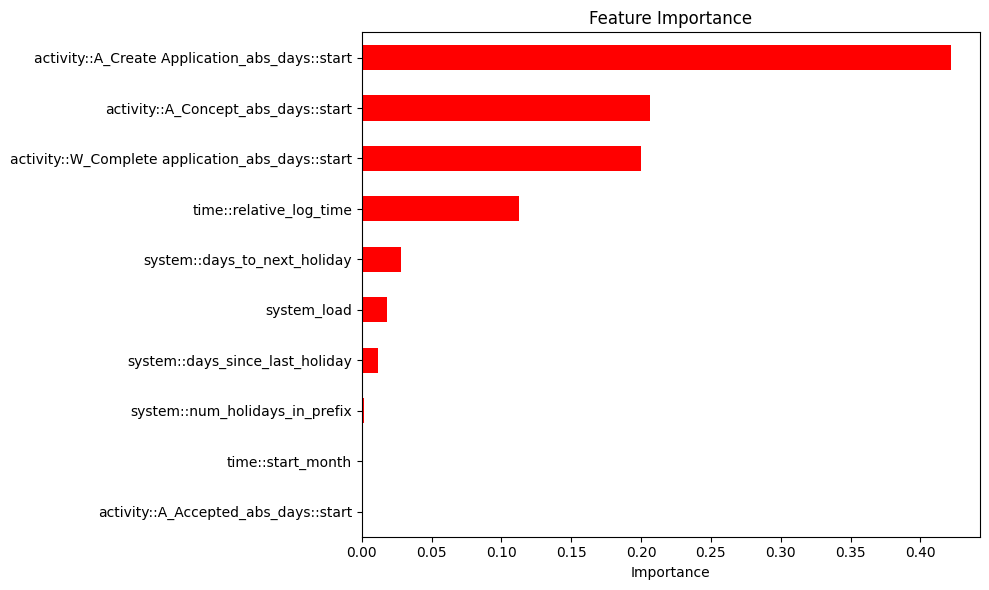

In [32]:
importances = pd.Series(model.feature_importances_, index=X_train.columns)
importances.sort_values().tail(10).plot(kind='barh', figsize=(10, 6), color='r')
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [33]:
pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(10)

activity::A_Create Application_abs_days::start      0.421633
activity::A_Concept_abs_days::start                 0.206322
activity::W_Complete application_abs_days::start    0.199768
time::relative_log_time                             0.112588
system::days_to_next_holiday                        0.028213
system_load                                         0.017758
system::days_since_last_holiday                     0.011228
system::num_holidays_in_prefix                      0.001327
time::start_month                                   0.000984
activity::A_Accepted_abs_days::start                0.000024
dtype: float64

# Results

## Ablation Study

In [34]:
high_level_variants, granular_variants = get_ablation_variants(X_train)

In [35]:
bpic17_results_high = run_ablation(X_train, X_test, y_train, y_test, high_level_variants)

In [36]:
bpic17_results_low = run_ablation(X_train, X_test, y_train, y_test, granular_variants)

In [37]:
display(bpic17_results_high)
display(bpic17_results_low)

,Variant,MAE,RMSE,R2,N Features
0,Raw sequence,87.145,102.776,-0.028,27
1,+ Case-level features,88.292,106.131,-0.096,31
2,+ Event-level features,7.629,10.726,0.989,115
3,+ System-level features,0.524,3.236,0.999,119
4,Full pipeline,0.326,3.107,0.999,121


,Variant,MAE,RMSE,R2,N Features
0,Raw sequence,87.145,102.776,-0.028,27
1,+ Case attributes,88.292,106.131,-0.096,31
2,+ Event aggregations,60.825,77.832,0.411,55
3,+ Activity start times,7.643,10.719,0.989,107
4,+ Temporal features,7.629,10.726,0.989,115
5,+ System features,0.524,3.236,0.999,119
6,Full pipeline,0.326,3.107,0.999,121


## Prediction Quality

In [38]:
plot_df = pd.DataFrame({
    'Actual (days)': y_test.values,
    'Predicted (days)': y_pred
})

reference_date = pd.Timestamp('2016-01-01', tz='UTC')
plot_df['Year'] = (reference_date + pd.to_timedelta(plot_df['Actual (days)'], unit='D')).dt.year.astype(str)

fig = px.scatter(
    plot_df,
    x='Actual (days)',
    y='Predicted (days)',
    color='Year',
    marginal_x='histogram',
    marginal_y='histogram',
    title='Actual vs Predicted Time to Loan Completion',
    opacity=0.6
)
fig.add_shape(
    type='line',
    x0=plot_df['Actual (days)'].min(),
    y0=plot_df['Actual (days)'].min(),
    x1=plot_df['Actual (days)'].max(),
    y1=plot_df['Actual (days)'].max(),
    line=dict(color='red', dash='dash', width=2)
)
fig.show()

In [39]:
results_df = pd.DataFrame({
    'case_id': prefix_log_test['case::case:concept:name'].values,
    'prefix_length': prefix_log_test['meta::prefix_length'].values,
    'actual': y_test.values,
    'predicted': y_pred,
    'error': abs(y_test.values - y_pred)
})

mae_by_prefix = results_df.groupby('prefix_length').apply(
    lambda g: mean_absolute_error(g['actual'], g['predicted'])
).reset_index()
mae_by_prefix.columns = ['Prefix Length', 'MAE (days)']

fig = px.line(
    mae_by_prefix,
    x='Prefix Length',
    y='MAE (days)',
    title='Average Prediction Error by Prefix Length',
    markers=True
)
fig.show()

/var/folders/m3/k3b3svlj7tvdqbtttg5w9xfw0000gn/T/ipykernel_41674/924791770.py:9: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [40]:
print(results_df[results_df["prefix_length"] == 11])

                     case_id  prefix_length  actual  predicted  error
902   Application_1489581984             11     340     339.68   0.32
1492  Application_1837817873             11     304     304.96   0.96
1870  Application_2056174200             11     322     321.88   0.12
2220   Application_314497877             11     387     372.59  14.41
2588   Application_521099293             11     296     296.00   0.00
3280   Application_936417560             11     347     347.33   0.33


In [41]:
print(results_df[abs(results_df["predicted"] - results_df["actual"]) > 1.0])

                     case_id  prefix_length  actual  predicted   error
37    Application_1018407971             15     164     162.74    1.26
312   Application_1175493423             18     355     353.48    1.52
472   Application_1270884238             15     254     255.06    1.06
558    Application_130761111             20     327     331.04    4.04
589   Application_1325688900             22     251     249.86    1.14
610     Application_13372270             16      16      17.05    1.05
722   Application_1394633662             21     391     389.95    1.05
726   Application_1395988794             24      73      74.54    1.54
846   Application_1463894255             15     254     255.04    1.04
921   Application_1507404560             19     132     130.83    1.17
1046   Application_157155173             15     381     253.57  127.43
1103  Application_1600531431             21     124     127.11    3.11
1230  Application_1681112710             16     141     139.91    1.09
1254  

In [42]:
bpic17_outliers = results_df[results_df['error'] > 5]
display(prefix_log_test.iloc[bpic17_outliers.index])

,case::case:LoanGoal,case::case:ApplicationType,case::case:concept:name,case::case:RequestedAmount,event::Action_last,event::org:resource_last,event::concept:name_last,event::EventOrigin_last,event::EventID_last,event::lifecycle:transition_last,...,meta::prefix_length,time::avg_time_between_events,time::max_time_between_events,system::number_of_unique_resources,system::num_holidays_in_prefix,system::days_to_next_holiday,system::days_since_last_holiday,system_load,target,system::duration_vs_period_avg
5021,Remaining debt home,New credit,Application_157155173,16500.0,Released,User_58,W_Call after offers,Workflow,Workitem_470185937,suspend,...,15,0.066667,1.0,2,3,88,15,589,381,-1.606545
8341,Car,New credit,Application_1954964010,40000.0,Released,User_41,W_Call after offers,Workflow,Workitem_1180432552,suspend,...,19,0.105263,2.0,2,3,27,3,1609,89,-0.511330
8342,Car,New credit,Application_1955037299,8000.0,Released,User_5,W_Call after offers,Workflow,Workitem_1777701362,suspend,...,15,0.200000,3.0,2,3,20,10,1571,97,0.488670
9056,Existing loan takeover,New credit,Application_2041082181,7500.0,Released,User_10,W_Call after offers,Workflow,Workitem_969261854,suspend,...,16,0.062500,1.0,2,7,202,21,1514,157,-1.511330
9424,Remaining debt home,New credit,Application_2077514757,25000.0,Released,User_41,W_Call after offers,Workflow,Workitem_376643590,suspend,...,24,0.041667,1.0,3,4,222,1,1535,136,-1.928225
10909,Car,New credit,Application_314497877,6500.0,Released,User_80,W_Complete application,Workflow,Workitem_1916822154,suspend,...,11,0.090909,1.0,3,3,81,22,391,387,-1.720601
12085,Home improvement,Limit raise,Application_447781816,15000.0,Released,User_4,W_Complete application,Workflow,Workitem_1197538983,suspend,...,15,0.000000,0.0,4,2,3,7,1522,132,-2.928225
14611,Remaining debt home,New credit,Application_739325744,75000.0,Released,User_42,W_Call after offers,Workflow,Workitem_510497731,suspend,...,17,0.117647,2.0,3,3,78,25,183,390,0.393455
16301,Existing loan takeover,New credit,Application_932158358,38500.0,Released,User_78,W_Call after offers,Workflow,Workitem_1263501662,suspend,...,33,0.030303,1.0,6,0,34,189,2196,325,-1.606545


In [43]:
results_df.groupby('prefix_length').size()

prefix_length
5       1
6       3
7       6
8      25
9      12
10     26
11      6
12     16
13     97
14     39
15    585
16    322
17    407
18    423
19    344
20    230
21    238
22    137
23    113
24     81
25     59
26     50
27     41
28     20
29     24
30     19
31     13
32      8
33      8
34      4
35      7
36      2
37      4
38      2
39      6
40      4
41      1
42      1
43      2
44      1
46      1
47      1
48      1
51      2
52      1
54      1
61      1
62      1
94      1
dtype: int64

In [44]:
print(mae_by_prefix)

    Prefix Length  MAE (days)
0               5    0.030000
1               6    0.540000
2               7    0.278333
3               8    0.231200
4               9    0.453333
5              10    0.268462
6              11    2.690000
7              12    0.276250
8              13    0.192784
9              14    0.256923
10             15    0.496154
11             16    0.311770
12             17    0.503636
13             18    0.215366
14             19    0.226366
15             20    0.255087
16             21    0.252353
17             22    0.223285
18             23    0.223451
19             24    0.264198
20             25    0.227627
21             26    0.192000
22             27    0.137073
23             28    0.231000
24             29    0.245417
25             30    0.270526
26             31    0.414615
27             32    0.308750
28             33    1.360000
29             34    0.375000
30             35    0.237143
31             36    1.930000
32        

In [45]:

# BPIC17
print(f"Actual range: {y_test.min()} - {y_test.max()}")
print(f"Predicted range: {y_pred.min():.1f} - {y_pred.max():.1f}")

Actual range: 10 - 396
Predicted range: 10.0 - 395.9


### Single Feature Ablation Study

In [46]:
variants = get_targeted_variants(X_train, 'activity::A_Create Application_abs_days::start')
results, importances = run_ablation_with_importance(X_train, X_test, y_train, y_test, variants)
display(results)
for name, importance in importances.items():
    print(f"\n{name}")
    display(importance)

,Variant,MAE,RMSE,R2,N Features
0,Full pipeline,0.326,3.107,0.999,121
1,Without relative_log_time,0.322,3.076,0.999,120
2,Without activity::A_Create Application_abs_days::start,0.321,3.037,0.999,120
3,Without both,0.318,2.988,0.999,119



Full pipeline


activity::A_Create Application_abs_days::start      0.421633
activity::A_Concept_abs_days::start                 0.206322
activity::W_Complete application_abs_days::start    0.199768
time::relative_log_time                             0.112588
system::days_to_next_holiday                        0.028213
system_load                                         0.017758
system::days_since_last_holiday                     0.011228
system::num_holidays_in_prefix                      0.001327
time::start_month                                   0.000984
activity::A_Accepted_abs_days::start                0.000024
dtype: float64


Without relative_log_time


activity::A_Create Application_abs_days::start        0.482179
activity::W_Complete application_abs_days::start      0.238954
activity::A_Concept_abs_days::start                   0.219093
system::days_to_next_holiday                          0.028188
system_load                                           0.018076
system::days_since_last_holiday                       0.010992
system::num_holidays_in_prefix                        0.001323
time::start_month                                     0.001003
event::concept:name_last                              0.000029
activity::O_Sent (mail and online)_abs_days::start    0.000025
dtype: float64


Without activity::A_Create Application_abs_days::start


activity::W_Complete application_abs_days::start    0.421852
activity::A_Concept_abs_days::start                 0.404050
time::relative_log_time                             0.114161
system::days_to_next_holiday                        0.029502
system_load                                         0.017791
system::days_since_last_holiday                     0.010095
system::num_holidays_in_prefix                      0.001397
time::start_month                                   0.000984
event::concept:name_last                            0.000021
activity::W_Call after offers_abs_days::start       0.000019
dtype: float64


Without both


activity::A_Concept_abs_days::start                 0.517759
activity::W_Complete application_abs_days::start    0.422565
system::days_to_next_holiday                        0.029247
system_load                                         0.017765
system::days_since_last_holiday                     0.009968
system::num_holidays_in_prefix                      0.001513
time::start_month                                   0.001001
activity::A_Complete_abs_days::start                0.000025
activity::O_Create Offer_abs_days::start            0.000020
event::concept:name_last                            0.000019
dtype: float64

In [47]:
case_cols = [col for col in X_train.columns if col.startswith('case::')]
variants = {'Full pipeline': list(X_train.columns)}
for col in case_cols:
    variants[f'Without {col}'] = [c for c in X_train.columns if c != col]

results_case, importances_case = run_ablation_with_importance(X_train, X_test, y_train, y_test, variants)
display(results_case)

,Variant,MAE,RMSE,R2,N Features
0,Full pipeline,0.326,3.107,0.999,121
1,Without case::case:LoanGoal,0.322,3.112,0.999,120
2,Without case::case:ApplicationType,0.325,3.132,0.999,120
3,Without case::case:concept:name,0.318,3.057,0.999,120
4,Without case::case:RequestedAmount,0.324,3.153,0.999,120


In [48]:
system_cols = [col for col in X_train.columns if col.startswith('system::')]
print(system_cols)
variants = {'Full pipeline': list(X_train.columns)}
for col in case_cols:
    variants[f'Without {col}'] = [c for c in X_train.columns if c != col]

results_case, importances_case = run_ablation_with_importance(X_train, X_test, y_train, y_test, variants)
display(results_case)

['system::number_of_unique_resources', 'system::num_holidays_in_prefix', 'system::days_to_next_holiday', 'system::days_since_last_holiday', 'system::duration_vs_period_avg']


,Variant,MAE,RMSE,R2,N Features
0,Full pipeline,0.326,3.107,0.999,121
1,Without case::case:LoanGoal,0.322,3.112,0.999,120
2,Without case::case:ApplicationType,0.325,3.132,0.999,120
3,Without case::case:concept:name,0.318,3.057,0.999,120
4,Without case::case:RequestedAmount,0.324,3.153,0.999,120


## Interpretability vs. Accuracy Trade-off

# Interpretation

In [49]:
import plotly.express as px
A_pending_events = event_log[event_log["concept:name"] == "A_Pending"]
fig = px.histogram(A_pending_events, x="relative_case_time")
fig.add_vline(x=5, line_width=3, line_dash="dash", line_color="red")
fig.show()

In [50]:
print(f"Cases: {event_log['case:concept:name'].nunique()}")
print(f"Events: {len(event_log)}")
print(f"Activities: {event_log['concept:name'].nunique()}")
print(f"Time span: {event_log['time:timestamp'].min()} to {event_log['time:timestamp'].max()}")
print(event_log.groupby('case:concept:name').size().describe())
print(event_log['concept:name'].unique())

Cases: 31509
Events: 1202267
Activities: 26
Time span: 2016-01-01 09:51:15.304000+00:00 to 2017-02-01 14:11:03.499000+00:00
count    31509.000000
mean        38.156305
std         16.715308
min         10.000000
25%         25.000000
50%         35.000000
75%         47.000000
max        180.000000
dtype: float64
['A_Create Application' 'A_Submitted' 'W_Handle leads'
 'W_Complete application' 'A_Concept' 'A_Accepted' 'O_Create Offer'
 'O_Created' 'O_Sent (mail and online)' 'W_Call after offers' 'A_Complete'
 'W_Validate application' 'A_Validating' 'O_Returned'
 'W_Call incomplete files' 'A_Incomplete' 'O_Accepted' 'A_Pending'
 'A_Denied' 'O_Refused' 'O_Cancelled' 'A_Cancelled' 'O_Sent (online only)'
 'W_Assess potential fraud' 'W_Personal Loan collection'
 'W_Shortened completion ']
